# Federated Learning DP Experiment Analysis

This notebook reads terminal output logs from four experiments: `non_dp.txt`, `local_only.txt`, `global_only.txt`, and `dp.txt`. It extracts round-level average accuracy and age-group Demographic Parity Gap values, then creates tables and plots for the final report.

The goal is to support the privacy–accuracy–fairness trade-off discussion with clean, reproducible evidence instead of only terminal screenshots.

In [12]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 1. Define experiment files

This section maps each text file to the correct privacy setting. These labels are important because the final report compares how different local and global DP noise settings affect accuracy and fairness.

In [13]:
log_files = {
    "No-DP": {
        "path": "non_dp.txt",
        "client_noise": 0.0,
        "server_noise": 0.0,
    },
    "Local DP Only": {
        "path": "local_only.txt",
        "client_noise": 0.1,
        "server_noise": 0.0,
    },
    "Global DP Only": {
        "path": "global_only.txt",
        "client_noise": 0.0,
        "server_noise": 0.05,
    },
    "Both DP": {
        "path": "dp.txt",
        "client_noise": 0.1,
        "server_noise": 0.05,
    },
}

for name, info in log_files.items():
    print(name, "->", Path(info["path"]).resolve(), "exists:", Path(info["path"]).exists())

No-DP -> /Users/kamaalalag/cse-467spring26/non_dp.txt exists: True
Local DP Only -> /Users/kamaalalag/cse-467spring26/local_only.txt exists: True
Global DP Only -> /Users/kamaalalag/cse-467spring26/global_only.txt exists: True
Both DP -> /Users/kamaalalag/cse-467spring26/dp.txt exists: True


## 2. Parser function

This function extracts the values needed for the final report:

- Average local accuracy before server aggregation for each round
- Demographic Parity Gaps for each round
- Average, minimum, and maximum fairness gap for each round

This is important because accuracy measures model utility, while Demographic Parity Gap measures fairness disparity across groups. Since gender and race outputs contain many `None` values, the analysis focuses on the valid age-group Demographic Parity Gap values.

In [14]:
def parse_experiment_log(file_path):
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path.resolve()}")

    text = file_path.read_text(errors="ignore")

    # Split text into round blocks. This works with logs that contain:
    # ROUND 1, ROUND 2, ...
    round_pattern = r"=+\s*\nROUND\s+(\d+)\s*\n=+"
    matches = list(re.finditer(round_pattern, text))

    rows = []

    for i, match in enumerate(matches):
        round_num = int(match.group(1))
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        block = text[start:end]

        # Extract average accuracy for this round
        acc_match = re.search(
            r"Average local accuracy before server aggregation:\s*([0-9]*\.?[0-9]+)",
            block
        )
        avg_accuracy = float(acc_match.group(1)) if acc_match else None

        # Extract all DP gaps printed in this round
        all_gap_matches = re.findall(
            r"Demographic Parity Gap:\s*([0-9]*\.?[0-9]+)",
            block
        )
        all_gaps = [float(x) for x in all_gap_matches]

        # Optional: because your reliable fairness metrics are from age clients 3, 6, 9,
        # we keep all numeric DP gaps. Gender/race with None do not create numeric gaps.
        avg_gap = sum(all_gaps) / len(all_gaps) if all_gaps else None
        min_gap = min(all_gaps) if all_gaps else None
        max_gap = max(all_gaps) if all_gaps else None

        rows.append({
            "round": round_num,
            "avg_accuracy": avg_accuracy,
            "avg_demographic_parity_gap": avg_gap,
            "min_demographic_parity_gap": min_gap,
            "max_demographic_parity_gap": max_gap,
            "num_fairness_gaps_found": len(all_gaps),
        })

    return pd.DataFrame(rows)

## 3. Parse all four experiments

This section reads all four text files and combines them into one results table. The table becomes the main source for final report tables and graphs.

In [15]:
all_results = []

for experiment_name, info in log_files.items():
    df = parse_experiment_log(info["path"])
    if df.empty:
        print(f"WARNING: No rounds found in {info['path']}. Check that the file contains lines like ROUND 1.")
    df["experiment"] = experiment_name
    df["client_noise"] = info["client_noise"]
    df["server_noise"] = info["server_noise"]
    all_results.append(df)

results_df = pd.concat(all_results, ignore_index=True)

important_cols = [
    "experiment",
    "client_noise",
    "server_noise",
    "round",
    "avg_accuracy",
    "avg_demographic_parity_gap",
    "min_demographic_parity_gap",
    "max_demographic_parity_gap",
    "num_fairness_gaps_found",
]

# Keep only columns that actually exist, so the notebook does not crash if a file is empty.
existing_important_cols = [c for c in important_cols if c in results_df.columns]
other_cols = [c for c in results_df.columns if c not in existing_important_cols]
results_df = results_df[existing_important_cols + other_cols]

results_df

,experiment,client_noise,server_noise,round,avg_accuracy,avg_demographic_parity_gap,min_demographic_parity_gap,max_demographic_parity_gap,num_fairness_gaps_found
0,No-DP,0.0,0.00,1,0.776,0.123252,0.090909,0.153846,3
1,No-DP,0.0,0.00,2,0.776,0.123252,0.090909,0.153846,3
2,No-DP,0.0,0.00,3,0.776,0.123252,0.090909,0.153846,3
3,No-DP,0.0,0.00,4,0.776,0.123252,0.090909,0.153846,3
4,No-DP,0.0,0.00,5,0.776,0.123252,0.090909,0.153846,3
5,Local DP Only,0.1,0.00,1,0.778,0.138636,0.090909,0.200000,3
6,Local DP Only,0.1,0.00,2,0.773,0.123252,0.090909,0.153846,3
7,Local DP Only,0.1,0.00,3,0.777,0.099129,0.052632,0.153846,3
8,Local DP Only,0.1,0.00,4,0.777,0.192696,0.090909,0.333333,3
9,Local DP Only,0.1,0.00,5,0.778,0.402159,0.052632,1.000000,3


## 4. Final round comparison table

This table uses the last available round from each experiment. It is the most useful table for the final report because it compares the final model behavior under each privacy setting.

In [16]:
final_round_df = (
    results_df
    .dropna(subset=["round"])
    .sort_values(["experiment", "round"])
    .groupby("experiment", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

final_round_df

,experiment,client_noise,server_noise,round,avg_accuracy,avg_demographic_parity_gap,min_demographic_parity_gap,max_demographic_parity_gap,num_fairness_gaps_found
0,Both DP,0.1,0.05,5,0.777,0.150411,0.052632,0.307692,3
1,Global DP Only,0.0,0.05,5,0.776,0.123252,0.090909,0.153846,3
2,Local DP Only,0.1,0.00,5,0.778,0.402159,0.052632,1.000000,3
3,No-DP,0.0,0.00,5,0.776,0.123252,0.090909,0.153846,3


## 5. Save report-ready CSV files

These CSV files make your results reproducible and easy to include in the report or appendix.

In [17]:
results_df.to_csv("all_experiment_results.csv", index=False)
final_round_df.to_csv("final_round_comparison.csv", index=False)

print("Saved all_experiment_results.csv")
print("Saved final_round_comparison.csv")

Saved all_experiment_results.csv
Saved final_round_comparison.csv


## 6. Plot accuracy across rounds

This graph shows whether adding DP noise reduces model accuracy over the federated learning rounds.

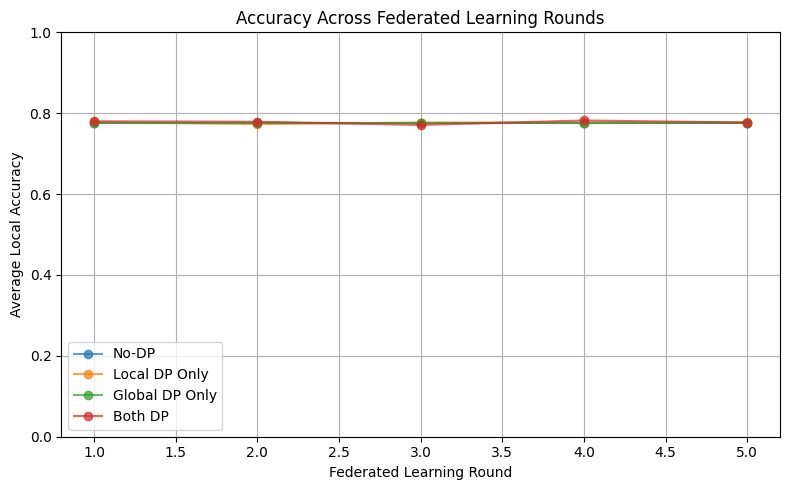

In [23]:
plt.figure(figsize=(8, 5))

for experiment in results_df["experiment"].dropna().unique():
    temp = results_df[results_df["experiment"] == experiment]
    plt.plot(temp["round"], temp["avg_accuracy"], marker='o', alpha=0.7, label=experiment)
plt.xlabel("Federated Learning Round")
plt.ylabel("Average Local Accuracy")
plt.title("Accuracy Across Federated Learning Rounds")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_across_rounds.png", dpi=300)
plt.show()

## 7. Plot fairness gap across rounds

This graph shows whether DP noise improves or worsens fairness. A lower Demographic Parity Gap means the model is more balanced across age groups.

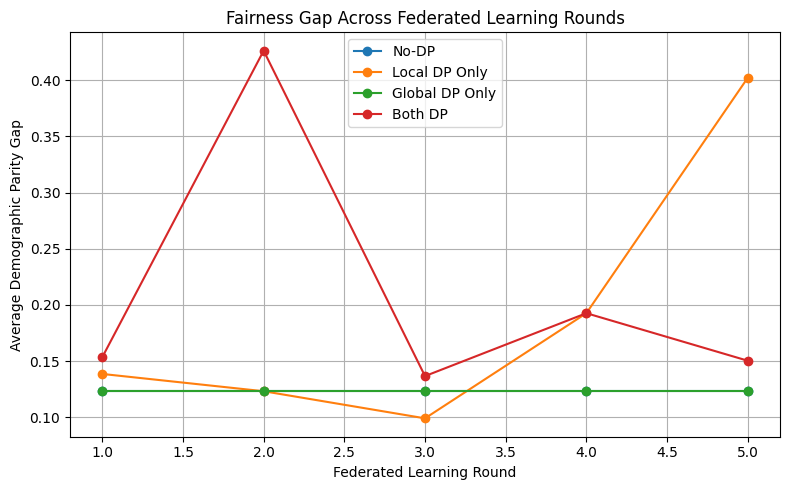

In [19]:
plt.figure(figsize=(8, 5))

for experiment in results_df["experiment"].dropna().unique():
    temp = results_df[results_df["experiment"] == experiment]
    plt.plot(temp["round"], temp["avg_demographic_parity_gap"], marker="o", label=experiment)

plt.xlabel("Federated Learning Round")
plt.ylabel("Average Demographic Parity Gap")
plt.title("Fairness Gap Across Federated Learning Rounds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("fairness_gap_across_rounds.png", dpi=300)
plt.show()

## 8. Final accuracy comparison

This graph compares final model accuracy across the four privacy configurations.

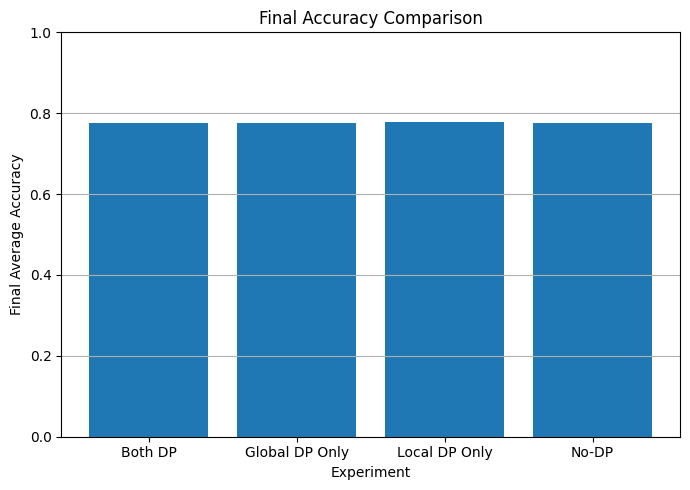

In [22]:
plt.figure(figsize=(7, 5))
plt.bar(final_round_df["experiment"], final_round_df["avg_accuracy"])
plt.xlabel("Experiment")
plt.ylabel("Final Average Accuracy")
plt.title("Final Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("final_accuracy_comparison.png", dpi=300)
plt.show()

## 9. Final fairness gap comparison

This graph compares the final Demographic Parity Gap across experiments. It supports the report discussion about the privacy-fairness trade-off.

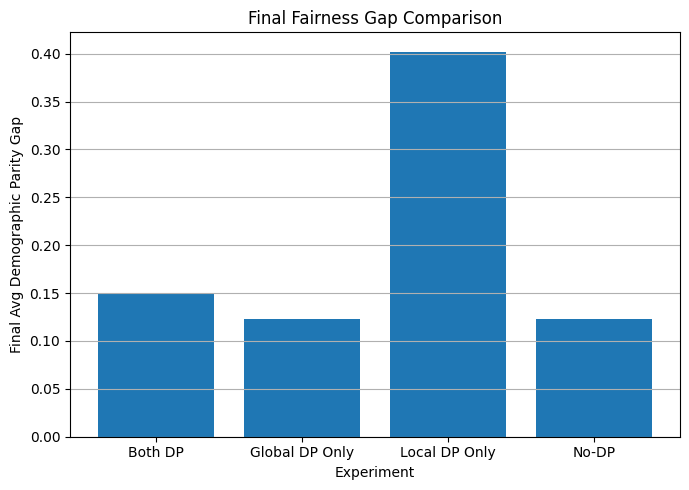

In [20]:
plt.figure(figsize=(7, 5))
plt.bar(final_round_df["experiment"], final_round_df["avg_demographic_parity_gap"])
plt.xlabel("Experiment")
plt.ylabel("Final Avg Demographic Parity Gap")
plt.title("Final Fairness Gap Comparison")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("final_fairness_gap_comparison.png", dpi=300)
plt.show()

## 10. Report-ready written summary

This prints a short interpretation that can be copied into the final report.

In [21]:
for _, row in final_round_df.iterrows():
    print(
        f"{row['experiment']}: "
        f"client noise={row['client_noise']}, "
        f"server noise={row['server_noise']}, "
        f"final accuracy={row['avg_accuracy']:.4f}, "
        f"final avg demographic parity gap={row['avg_demographic_parity_gap']:.4f}"
    )

Both DP: client noise=0.1, server noise=0.05, final accuracy=0.7770, final avg demographic parity gap=0.1504
Global DP Only: client noise=0.0, server noise=0.05, final accuracy=0.7760, final avg demographic parity gap=0.1233
Local DP Only: client noise=0.1, server noise=0.0, final accuracy=0.7780, final avg demographic parity gap=0.4022
No-DP: client noise=0.0, server noise=0.0, final accuracy=0.7760, final avg demographic parity gap=0.1233
